<a href="https://colab.research.google.com/github/Carmen10-171/01MIAR_ABR26/blob/main/01MIAR_ACT_Dataset_Banca_rev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01MIAR - Actividad Dataset
## Análisis predictivo de clientes potenciales en banca

**Dataset:** Bank Marketing Dataset - UCI Machine Learning Repository  
**Autora:** Mª Carmen Copé Soler  
**Asignatura:** Máster Universitario en Inteligencia Artificial  

Este notebook desarrolla un análisis completo sobre campañas de marketing bancario, incorporando una fase de análisis exploratorio, preparación correcta de datos y una sección final de modelado predictivo con técnicas de Machine Learning.

La mejora principal respecto a una versión inicial consiste en:

- Eliminar el error asociado a `model_dataset` no definido.
- Corregir el tratamiento de variables categóricas mediante One-Hot Encoding solo donde corresponde.
- Mantener las variables numéricas como numéricas y escalarlas correctamente.
- Añadir modelos predictivos de clasificación: **Logistic Regression** y **Random Forest**.
- Evaluar los resultados con métricas adecuadas, especialmente teniendo en cuenta el desbalanceo de clases.


## 1. Contextualización del caso real

El conjunto de datos utilizado recoge información de campañas de marketing directo realizadas por una entidad bancaria portuguesa. El objetivo de dichas campañas era contactar con clientes para ofrecerles la contratación de un depósito a plazo.

Desde el punto de vista de la Inteligencia Artificial, el caso es especialmente interesante porque permite abordar un problema real de **clasificación supervisada**: predecir si un cliente contratará o no el producto financiero ofrecido.

La variable objetivo es:

- `y = yes`: el cliente contrató el depósito.
- `y = no`: el cliente no contrató el depósito.

Este tipo de análisis puede ayudar a una entidad financiera o a una empresa de servicios tecnológicos a priorizar clientes con mayor probabilidad de conversión, optimizar campañas comerciales y reducir costes de contacto.


## 2. Importación de librerías

Se importan las librerías necesarias para la carga de datos, análisis exploratorio, visualización y modelado predictivo.


In [1]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 3. Carga del dataset

El dataset se descarga directamente desde el repositorio oficial de UCI. Se utiliza el fichero `bank-additional-full.csv`, que contiene 41.188 registros y 21 variables.


In [2]:
# ==========================================================
# CARGA DEL DATASET DESDE UCI
# ==========================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

response = requests.get(url)
response.raise_for_status()

z = zipfile.ZipFile(BytesIO(response.content))

with z.open("bank-additional/bank-additional-full.csv") as f:
    bank_dataset = pd.read_csv(f, sep=";")

print("Dimensiones del dataset:", bank_dataset.shape)
bank_dataset.head()


Dimensiones del dataset: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no


## 4. Descripción inicial del dataset

En esta fase se revisa la estructura de los datos, los tipos de variables, los valores ausentes y una descripción estadística inicial.


In [3]:
# Información general del dataset
bank_dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# Comprobación de valores ausentes
missing_values = bank_dataset.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


,0


In [5]:
# Estadísticos descriptivos de las variables numéricas
bank_dataset.describe().T.round(4)


,count,mean,std,min,25%,50%,75%,max
age,41188.0000,40.0241,10.4212,17.0000,32.0000,38.0000,47.0000,98.0000
duration,41188.0000,258.2850,259.2792,0.0000,102.0000,180.0000,319.0000,4918.0000
campaign,41188.0000,2.5676,2.7700,1.0000,1.0000,2.0000,3.0000,56.0000
pdays,41188.0000,962.4755,186.9109,0.0000,999.0000,999.0000,999.0000,999.0000
previous,41188.0000,0.1730,0.4949,0.0000,0.0000,0.0000,0.0000,7.0000
emp.var.rate,41188.0000,0.0819,1.5710,-3.4000,-1.8000,1.1000,1.4000,1.4000
cons.price.idx,41188.0000,93.5757,0.5788,92.2010,93.0750,93.7490,93.9940,94.7670
cons.conf.idx,41188.0000,-40.5026,4.6282,-50.8000,-42.7000,-41.8000,-36.4000,-26.9000
euribor3m,41188.0000,3.6213,1.7344,0.6340,1.3440,4.8570,4.9610,5.0450
nr.employed,41188.0000,5167.0359,72.2515,4963.6000,5099.1000,5191.0000,5228.1000,5228.1000


In [6]:
# Resumen de variables categóricas
categorical_summary = pd.DataFrame({
    "variable": bank_dataset.select_dtypes(include="object").columns,
    "n_categorias": [bank_dataset[col].nunique() for col in bank_dataset.select_dtypes(include="object").columns]
})

categorical_summary


,variable,n_categorias
0,job,12
1,marital,4
2,education,8
3,default,3
4,housing,3
5,loan,3
6,contact,2
7,month,10
8,day_of_week,5
9,poutcome,3


## 5. Análisis exploratorio de datos

El análisis exploratorio permite entender la composición del dataset antes de construir modelos predictivos. Se revisa la distribución de la variable objetivo, variables demográficas, canales de contacto y relación entre duración de llamada y contratación.


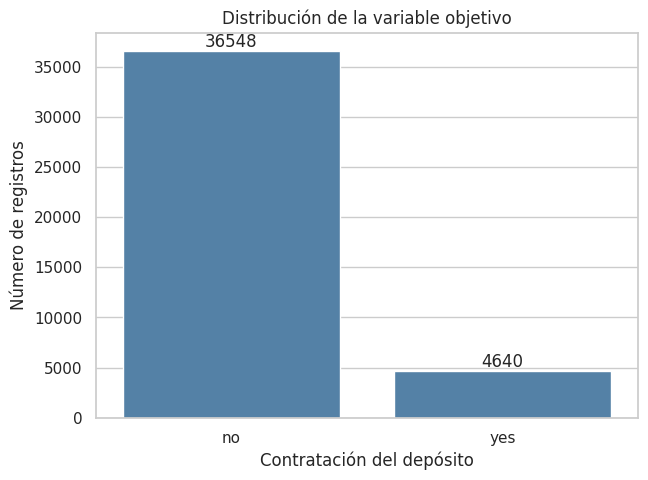

,proportion
y,
no,88.7346
yes,11.2654


In [7]:
# Distribución de la variable objetivo
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=bank_dataset, x="y", color="steelblue")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Contratación del depósito")
plt.ylabel("Número de registros")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

class_balance = bank_dataset["y"].value_counts(normalize=True) * 100
class_balance.round(4)


La variable objetivo está desbalanceada, ya que la mayoría de clientes no contrataron el depósito. Este punto es relevante porque una métrica como `accuracy` puede ser insuficiente si se interpreta de forma aislada. Por ello, se evaluarán también `precision`, `recall`, `F1-score` y `ROC-AUC`.


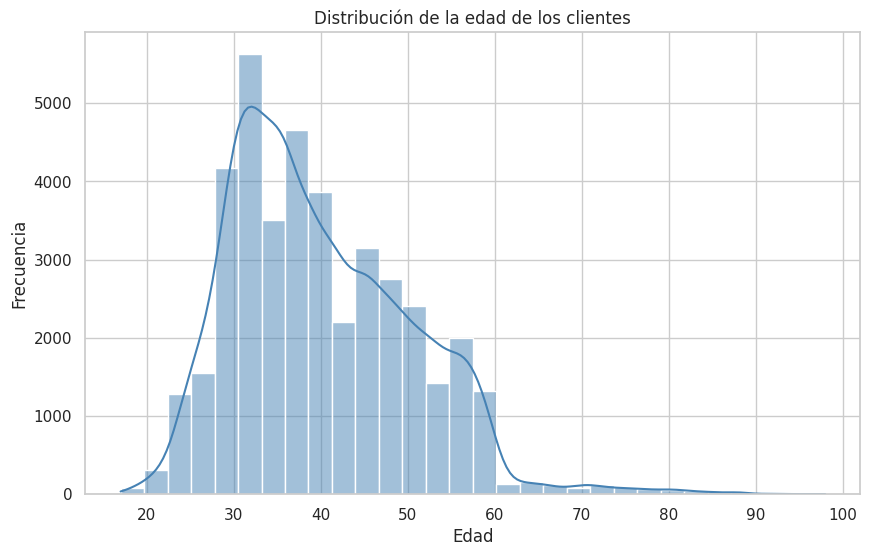

In [8]:
# Distribución de edad
plt.figure(figsize=(10, 6))
sns.histplot(bank_dataset["age"], bins=30, kde=True, color="steelblue")
plt.title("Distribución de la edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


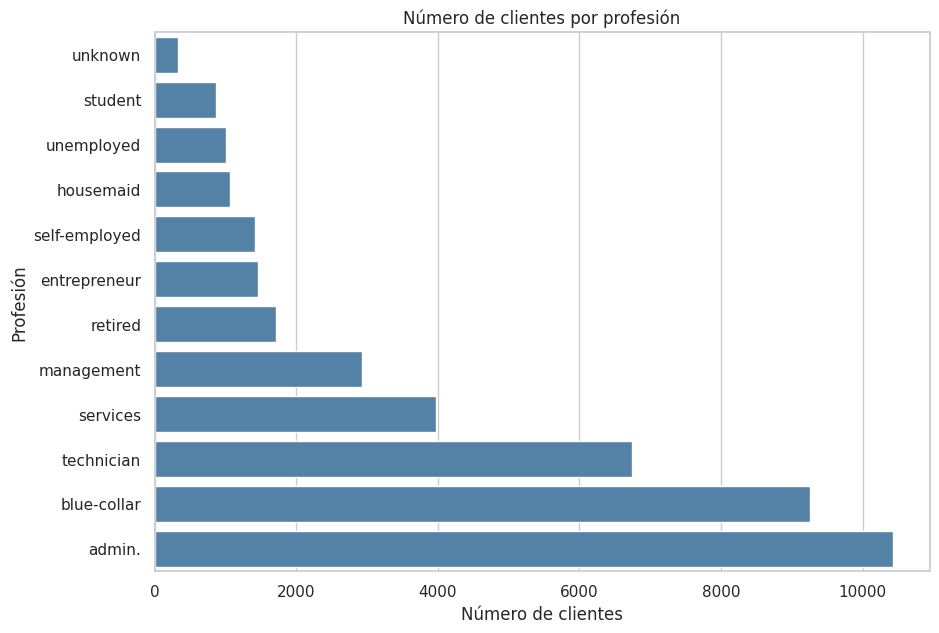

In [9]:
# Clientes por profesión
job_counts = bank_dataset["job"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(x=job_counts.values, y=job_counts.index, color="steelblue")
plt.title("Número de clientes por profesión")
plt.xlabel("Número de clientes")
plt.ylabel("Profesión")
plt.show()


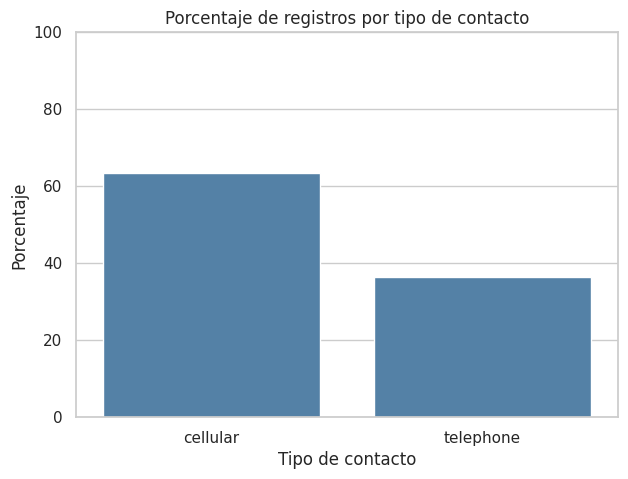

,proportion
contact,
cellular,63.4748
telephone,36.5252


In [10]:
# Tipo de contacto utilizado
contact_counts = bank_dataset["contact"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=contact_counts.index, y=contact_counts.values, color="steelblue")
plt.title("Porcentaje de registros por tipo de contacto")
plt.xlabel("Tipo de contacto")
plt.ylabel("Porcentaje")
plt.ylim(0, 100)
plt.show()

contact_counts.round(4)


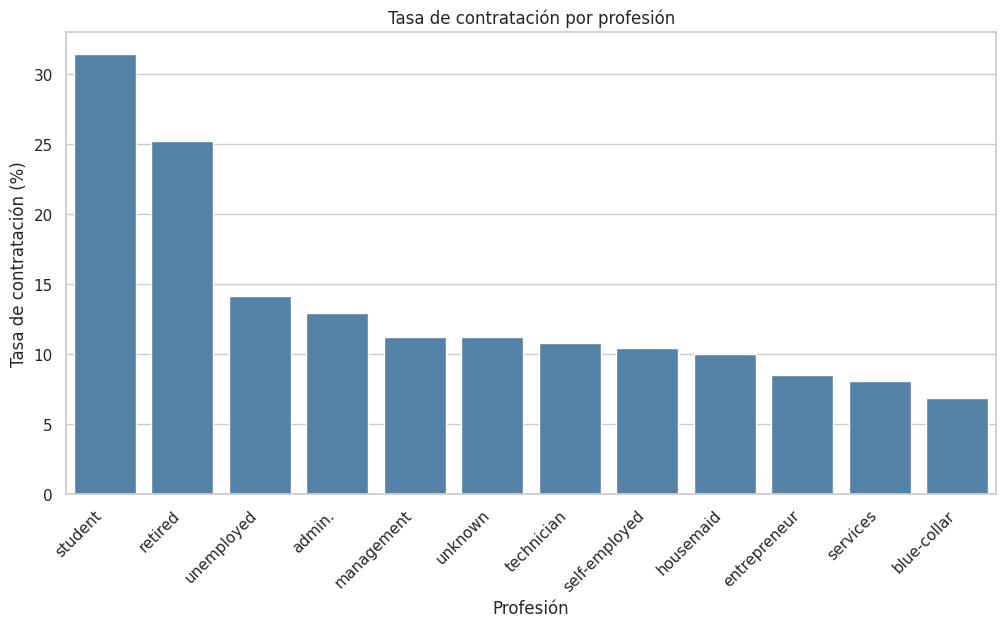

,y
job,
student,31.4286
retired,25.2326
unemployed,14.2012
admin.,12.9726
management,11.2175
unknown,11.2121
technician,10.8260
self-employed,10.4856
housemaid,10.0000


In [11]:
# Tasa de conversión por profesión
conversion_job = (
    bank_dataset
    .groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=conversion_job.index, y=conversion_job.values, color="steelblue")
plt.title("Tasa de contratación por profesión")
plt.xlabel("Profesión")
plt.ylabel("Tasa de contratación (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

conversion_job.round(4)


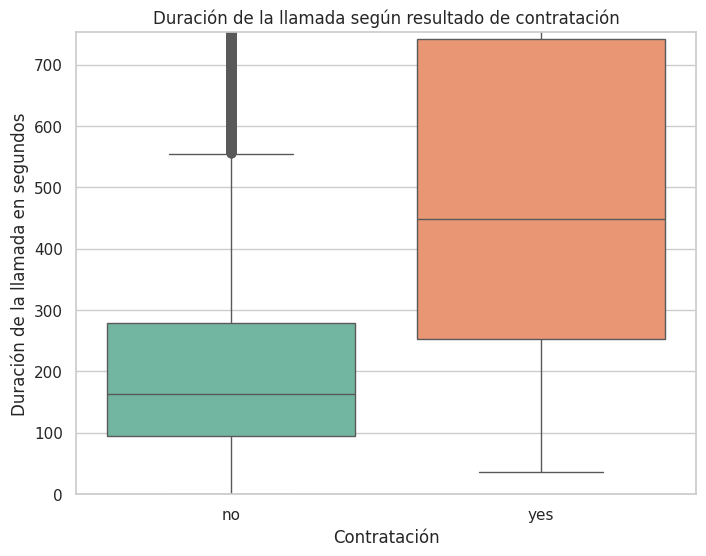

In [12]:
# Duración de llamada según resultado
plt.figure(figsize=(8, 6))
sns.boxplot(data=bank_dataset, x="y", y="duration", hue="y", palette="Set2", legend=False)
plt.title("Duración de la llamada según resultado de contratación")
plt.xlabel("Contratación")
plt.ylabel("Duración de la llamada en segundos")
plt.ylim(0, bank_dataset["duration"].quantile(0.95))
plt.show()


La duración de la llamada suele aparecer como una variable muy relacionada con la conversión. No obstante, debe interpretarse con cautela: en un escenario real, la duración completa de la llamada solo se conoce después del contacto, por lo que puede introducir fuga de información si se usa para predecir antes de llamar al cliente. En este trabajo se mantiene para fines académicos, pero se comenta esta limitación en la conclusión.


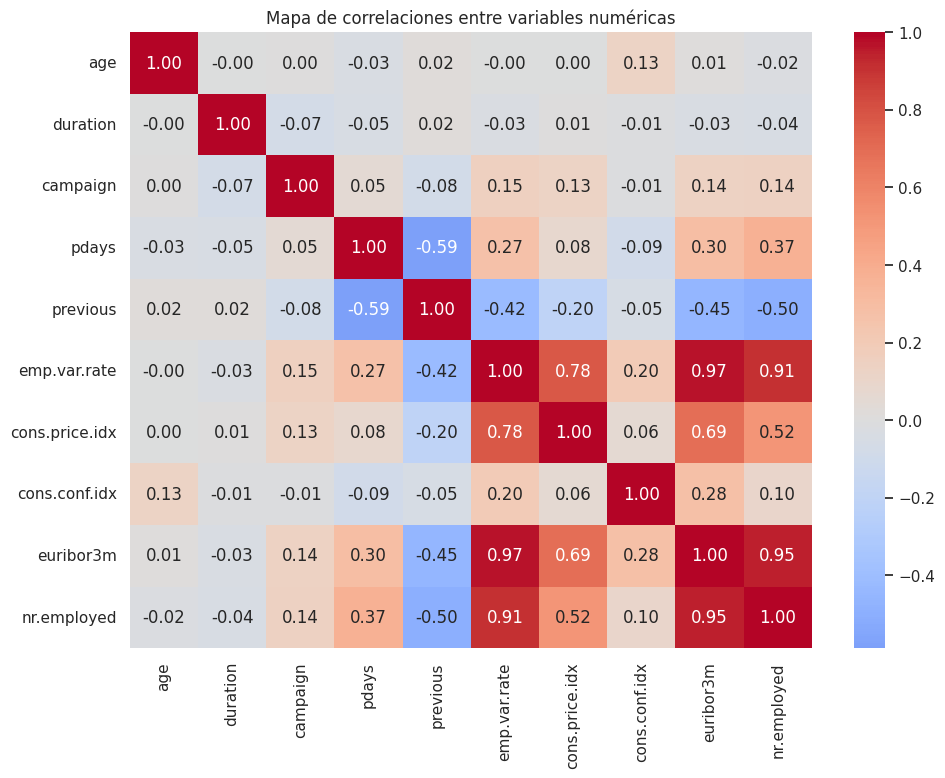

In [13]:
# Mapa de correlaciones de variables numéricas
numeric_cols_original = bank_dataset.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(11, 8))
sns.heatmap(bank_dataset[numeric_cols_original].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de correlaciones entre variables numéricas")
plt.show()


## 6. Preparación correcta de los datos para Machine Learning

En esta sección se corrige el principal problema de la versión inicial: no se deben convertir todas las columnas en variables dummy. Las variables numéricas deben mantenerse como numéricas y las variables categóricas deben transformarse mediante One-Hot Encoding.

La preparación se realiza mediante un `ColumnTransformer`, que permite aplicar:

- `StandardScaler` a variables numéricas.
- `OneHotEncoder` a variables categóricas.

De este modo se evita el error de convertir variables continuas como `age`, `duration` o `euribor3m` en cientos de columnas binarias.


In [14]:
# ==========================================================
# PREPARACIÓN CORRECTA DEL DATASET
# ==========================================================

model_dataset = bank_dataset.copy()

# Conversión de la variable objetivo a formato binario
model_dataset["y"] = model_dataset["y"].map({"yes": 1, "no": 0})

# Separación entre variables predictoras y variable objetivo
X = model_dataset.drop("y", axis=1)
y = model_dataset["y"]

# Identificación automática de variables numéricas y categóricas
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)


Variables numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [15]:
# Preprocesamiento: escalado para numéricas y One-Hot Encoding para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)


## 7. División en entrenamiento y prueba

Se utiliza una división 80/20, manteniendo la proporción de clases mediante `stratify=y`. Esto es importante porque la variable objetivo está desbalanceada.


In [16]:
# División train/test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensión X_train:", X_train.shape)
print("Dimensión X_test:", X_test.shape)
print("Distribución en train:")
print(y_train.value_counts(normalize=True).round(4))
print("Distribución en test:")
print(y_test.value_counts(normalize=True).round(4))


Dimensión X_train: (32950, 20)
Dimensión X_test: (8238, 20)
Distribución en train:
y
0   0.8873
1   0.1127
Name: proportion, dtype: float64
Distribución en test:
y
0   0.8874
1   0.1126
Name: proportion, dtype: float64


## 8. Modelo 1: Logistic Regression

La Regresión Logística se utiliza como modelo base. Es adecuada para problemas de clasificación binaria y permite obtener una primera referencia de rendimiento.

Se utiliza `class_weight="balanced"` para compensar parcialmente el desbalanceo de clases.


In [17]:
# Pipeline de Regresión Logística
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)
y_proba_log = logistic_model.predict_proba(X_test)[:, 1]


In [18]:
# Evaluación de Logistic Regression
metrics_log = {
    "Modelo": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1": f1_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_proba_log)
}

pd.DataFrame([metrics_log]).round(4)


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8653,0.4514,0.9116,0.6039,0.9438


In [19]:
print(classification_report(y_test, y_pred_log, digits=4))


              precision    recall  f1-score   support

           0     0.9871    0.8594    0.9188      7310
           1     0.4514    0.9116    0.6039       928

    accuracy                         0.8653      8238
   macro avg     0.7193    0.8855    0.7613      8238
weighted avg     0.9268    0.8653    0.8833      8238



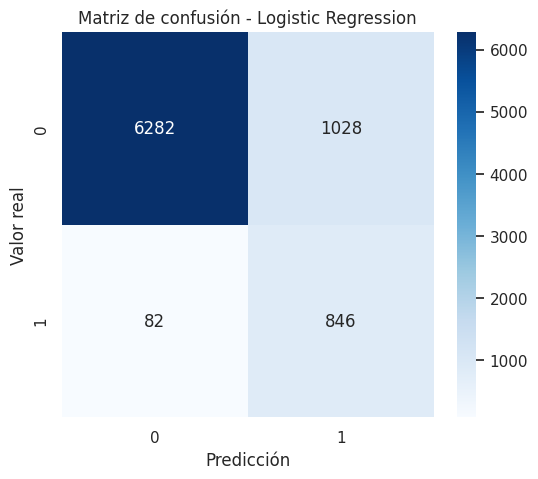

In [20]:
# Matriz de confusión - Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


## 9. Modelo 2: Random Forest

Random Forest es un modelo de ensamble basado en múltiples árboles de decisión. Suele funcionar bien con relaciones no lineales y permite obtener una estimación de la importancia de las variables.

También se utiliza `class_weight="balanced"` para tener en cuenta el desbalanceo de la variable objetivo.


In [21]:
# Pipeline de Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]


In [22]:
# Evaluación de Random Forest
metrics_rf = {
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
}

pd.DataFrame([metrics_rf]).round(4)


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.9167,0.7010,0.4547,0.5516,0.9505


In [23]:
print(classification_report(y_test, y_pred_rf, digits=4))


              precision    recall  f1-score   support

           0     0.9337    0.9754    0.9541      7310
           1     0.7010    0.4547    0.5516       928

    accuracy                         0.9167      8238
   macro avg     0.8174    0.7151    0.7529      8238
weighted avg     0.9075    0.9167    0.9088      8238



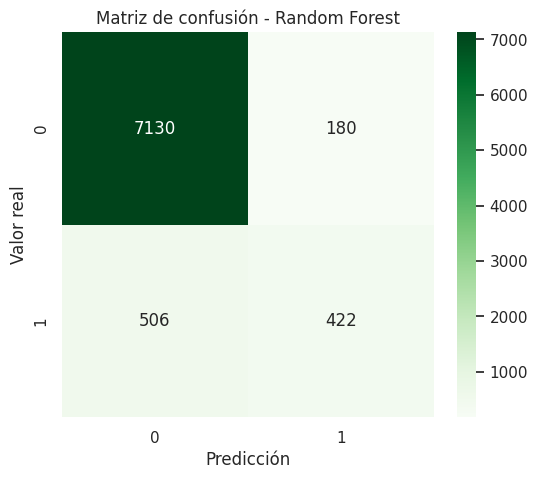

In [24]:
# Matriz de confusión - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()


## 10. Comparación de modelos

Se comparan ambos modelos utilizando las principales métricas de clasificación. En datasets desbalanceados, el F1-score y el ROC-AUC suelen aportar una visión más completa que la accuracy.


In [25]:
# Comparación de modelos
results = pd.DataFrame([metrics_log, metrics_rf])
results_rounded = results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    results_rounded[col] = results_rounded[col].round(4)

results_rounded


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8653,0.4514,0.9116,0.6039,0.9438
1,Random Forest,0.9167,0.7010,0.4547,0.5516,0.9505


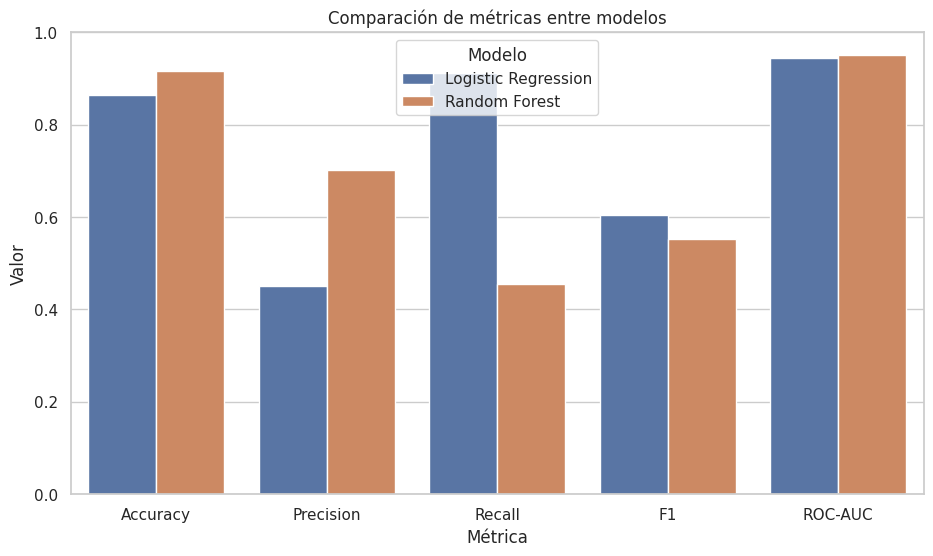

In [26]:
# Visualización comparativa de métricas
results_melted = results.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

plt.figure(figsize=(11, 6))
sns.barplot(data=results_melted, x="Métrica", y="Valor", hue="Modelo")
plt.title("Comparación de métricas entre modelos")
plt.ylim(0, 1)
plt.ylabel("Valor")
plt.show()


<Figure size 800x600 with 0 Axes>

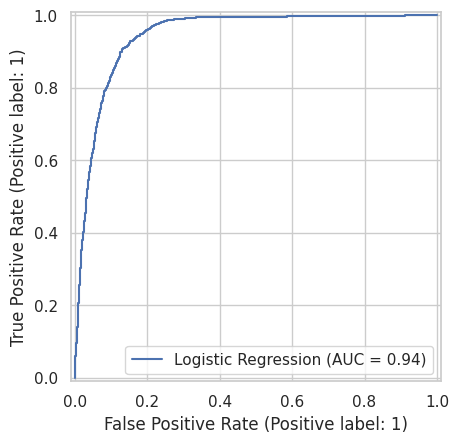

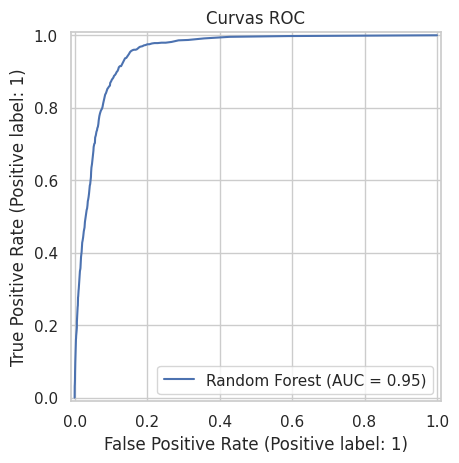

In [27]:
# Curvas ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest")
plt.title("Curvas ROC")
plt.show()


## 11. Importancia de variables en Random Forest

Una ventaja de Random Forest es que permite analizar qué variables han tenido mayor peso en la clasificación. Esto ayuda a interpretar el modelo desde una perspectiva de negocio.


In [28]:
# Recuperar nombres de variables tras el preprocesamiento
fitted_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

encoded_cat_features = fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([numeric_features, encoded_cat_features])

feature_importance = pd.DataFrame({
    "Variable": all_feature_names,
    "Importancia": rf_classifier.feature_importances_
}).sort_values("Importancia", ascending=False)

feature_importance.head(20).round(4)


,Variable,Importancia
1,duration,0.3846
8,euribor3m,0.0881
9,nr.employed,0.0676
0,age,0.0585
5,emp.var.rate,0.0554
7,cons.conf.idx,0.0317
2,campaign,0.0300
6,cons.price.idx,0.0254
3,pdays,0.0184
34,housing_yes,0.0126


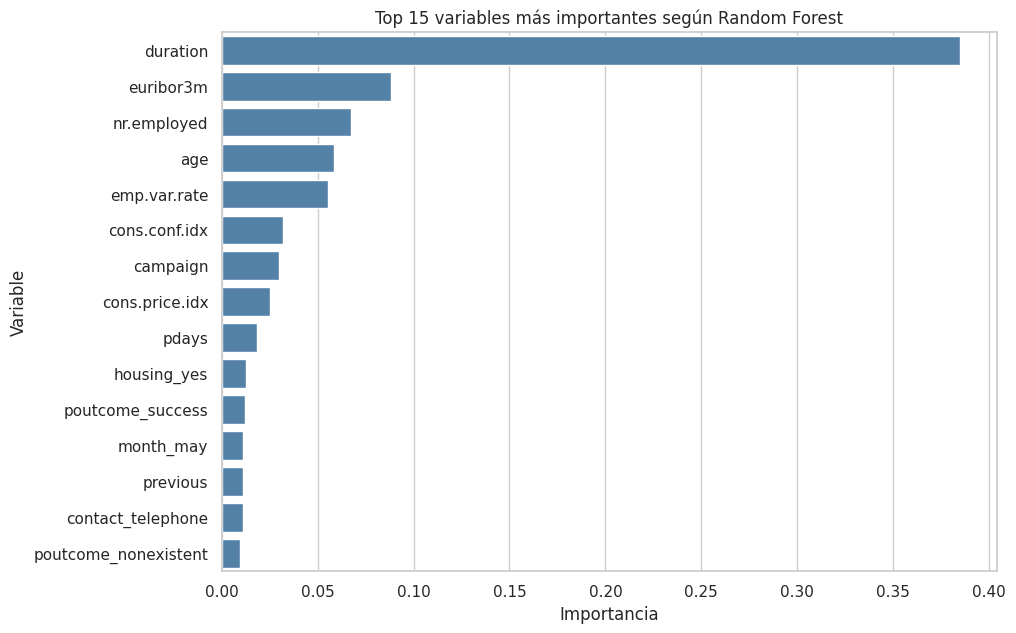

In [29]:
# Visualización de las variables más importantes
plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance.head(15),
    x="Importancia",
    y="Variable",
    color="steelblue"
)
plt.title("Top 15 variables más importantes según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


## 12. Interpretación académica de resultados

El análisis realizado permite extraer varias conclusiones relevantes:

1. El problema planteado es un caso claro de clasificación supervisada, ya que se intenta predecir si un cliente contratará o no un depósito bancario.
2. El dataset presenta desbalanceo de clases, dado que la mayoría de clientes no contrataron el producto. Por este motivo, no basta con analizar la accuracy, sino que es necesario revisar también precision, recall, F1-score y ROC-AUC.
3. La preparación del dato es una fase crítica. En este notebook se ha corregido el One-Hot Encoding para aplicarlo únicamente a variables categóricas, manteniendo las variables numéricas como tales.
4. Logistic Regression funciona como un modelo base interpretable, mientras que Random Forest permite capturar relaciones más complejas y ofrece una medida de importancia de variables.
5. La duración de la llamada puede aparecer como una variable muy influyente. Sin embargo, desde una perspectiva realista, debe interpretarse con cautela porque podría no estar disponible antes de realizar la llamada.
6. El análisis puede ayudar a optimizar campañas comerciales, priorizar clientes con mayor probabilidad de conversión y mejorar la eficiencia de los equipos de marketing.


## 13. Conclusión final

Este trabajo ha permitido desarrollar un flujo completo de análisis de datos e Inteligencia Artificial aplicado a un caso real del sector bancario. A partir del Bank Marketing Dataset se han realizado tareas de carga, exploración, limpieza, visualización, preparación de variables y modelado predictivo.

La principal aportación del notebook es la construcción de un proceso de Machine Learning correctamente estructurado. Se han separado las variables predictoras de la variable objetivo, se han tratado adecuadamente las variables categóricas mediante One-Hot Encoding y se han escalado las variables numéricas. Además, se han comparado dos modelos de clasificación: Logistic Regression y Random Forest.

Desde el punto de vista académico, el trabajo demuestra cómo las técnicas de IA pueden aplicarse a problemas reales de negocio, concretamente a la predicción de clientes con mayor probabilidad de contratar un producto financiero. Esto permite transformar datos históricos de campañas en conocimiento útil para la toma de decisiones.

Como mejora futura, sería recomendable probar técnicas adicionales de tratamiento del desbalanceo, como SMOTE, ajustar hiperparámetros mediante GridSearchCV y analizar modelos adicionales como XGBoost o LightGBM.


## 14. Declaración de uso de IA

Se han utilizado herramientas de inteligencia artificial generativa como apoyo para la mejora de la estructura del notebook, la redacción académica, la revisión del flujo de Machine Learning y la corrección de errores técnicos. La interpretación final y adaptación del contenido al caso de estudio han sido revisadas por la autora.


## 15. Referencias

- UCI Machine Learning Repository. Bank Marketing Dataset.  
- Moro, S., Cortez, P., & Rita, P. (2014). A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems.
- Documentación oficial de scikit-learn sobre `Pipeline`, `ColumnTransformer`, `LogisticRegression` y `RandomForestClassifier`.
